In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load data
df = pd.read_csv('../data/raw_data.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


Statistical Summary

In [2]:
# basic info
df.info()

# statistical summary
summary = df.describe()
print(summary)
print("==============================================")
# missing values
missing = df.isnull().sum()
print("\nMissing Values:\n", missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1024 non-null   float64
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1023 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 112.2 KB
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000 

In [3]:
missing = df.isnull().sum()
print("\nMissing Values:\n", missing)


Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64


Correlation Heatmap 

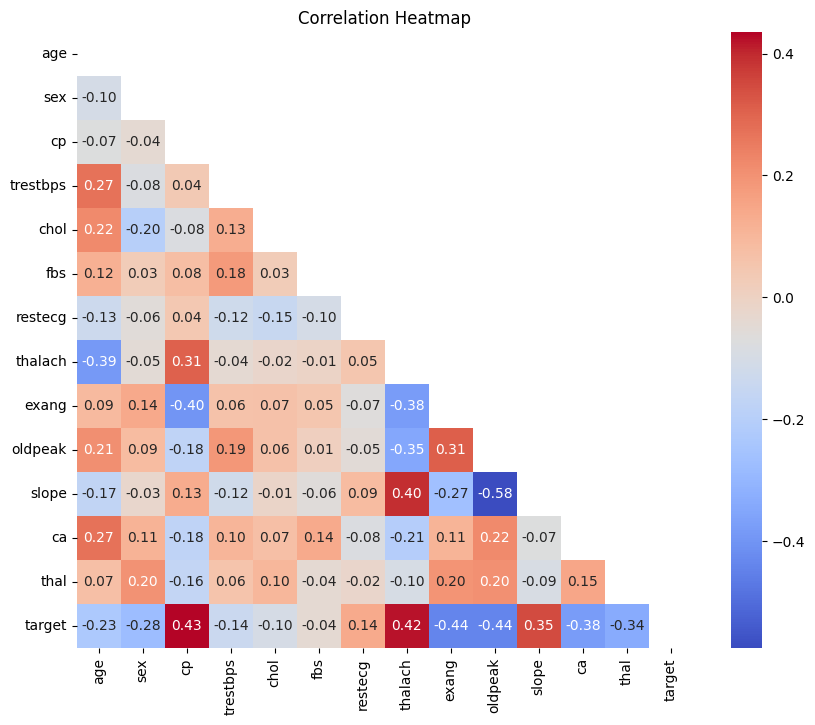

In [4]:
plt.figure(figsize=(10,8))

corr = df.corr()

# mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            square=True)

plt.title("Correlation Heatmap")
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

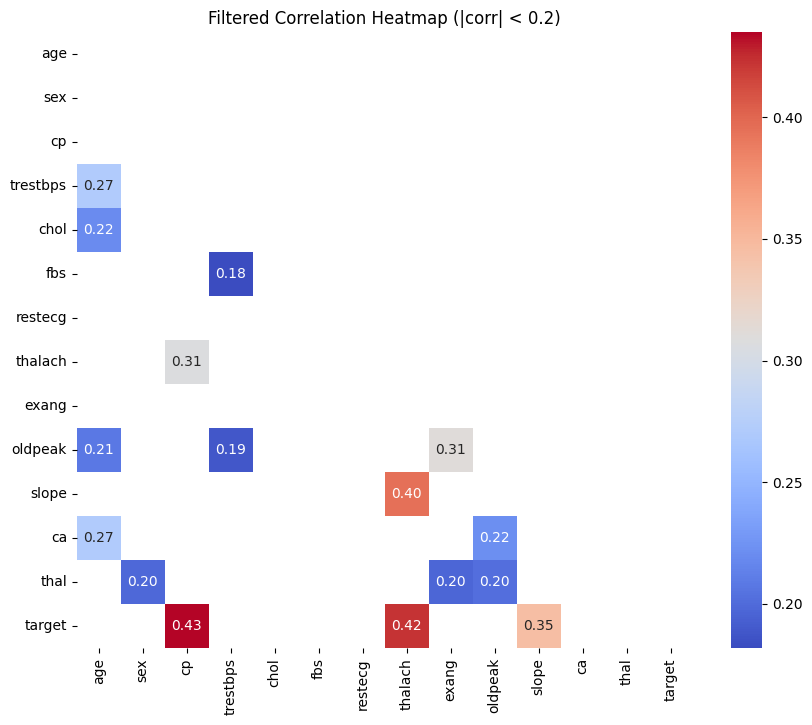

In [5]:
plt.figure(figsize=(10,8))

corr = df.corr()

# Filter correlations with absolute value less than 0.15
corr_filtered = corr.where((corr >= -0.15) & (corr >= 0.15))

# mask for upper triangle
mask = np.triu(np.ones_like(corr_filtered, dtype=bool))

sns.heatmap(corr_filtered, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            square=True)

plt.title("Filtered Correlation Heatmap (|corr| < 0.2)")
plt.savefig('filtered_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Histograms

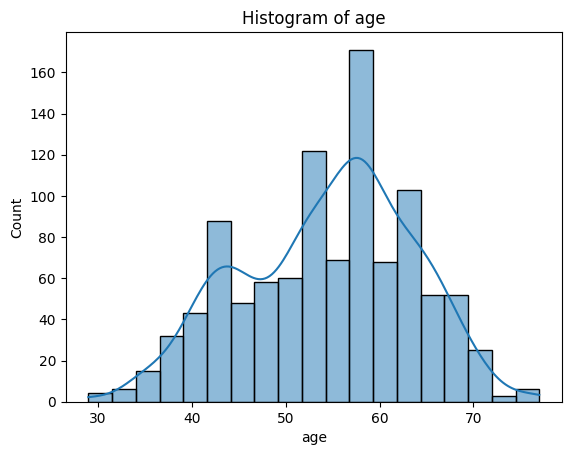

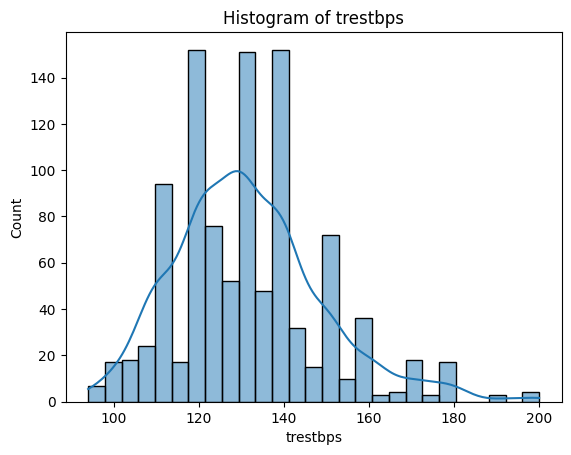

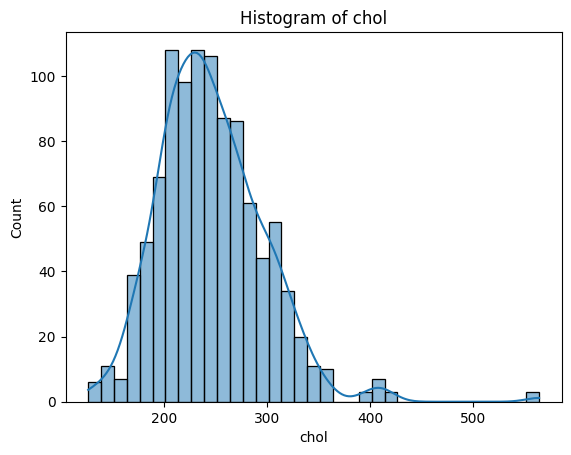

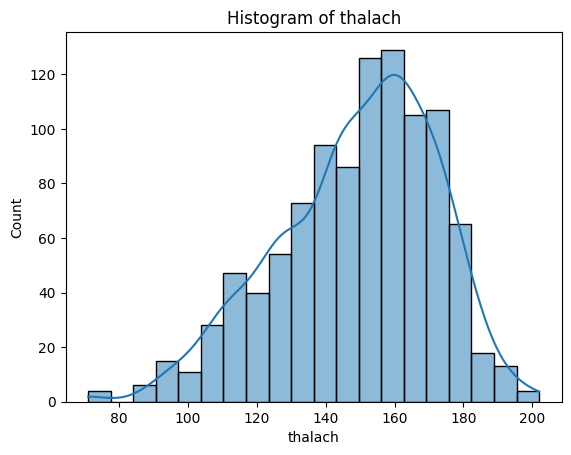

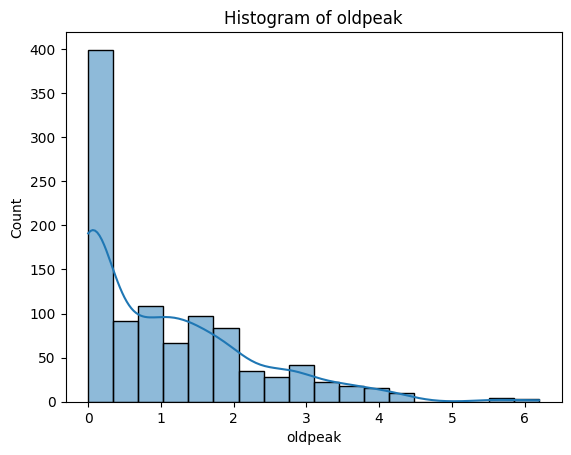

In [6]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.savefig(f'hist_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()

Boxplots

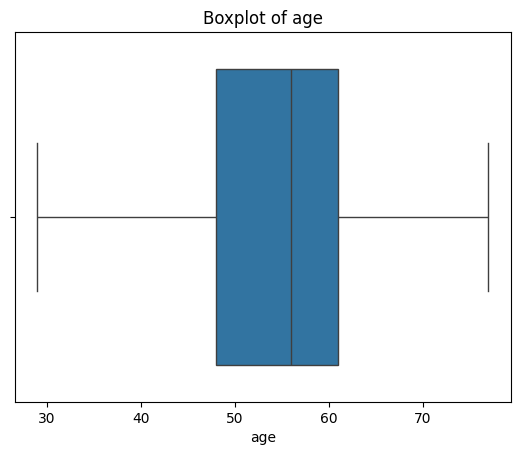

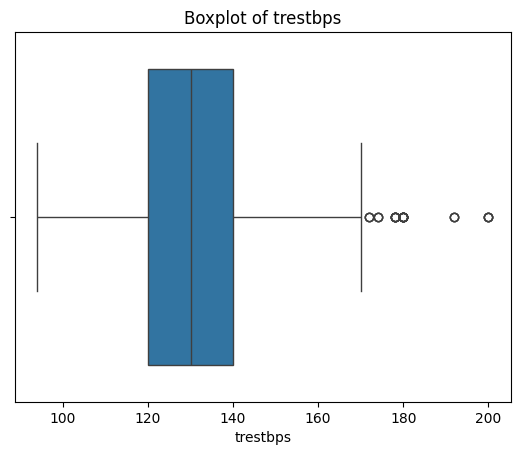

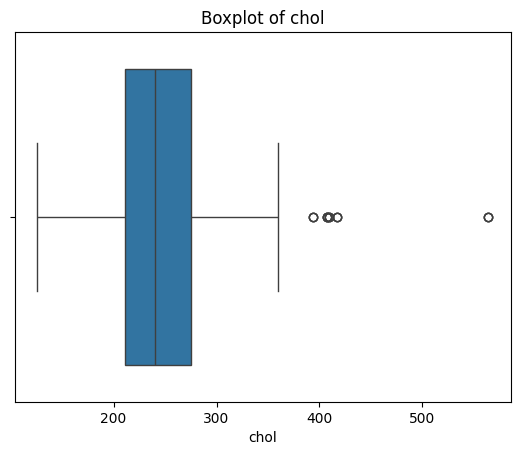

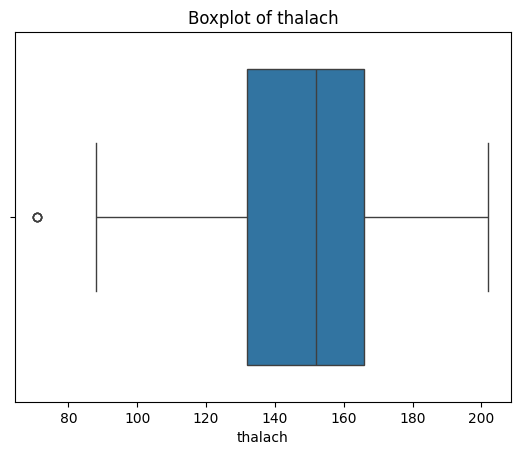

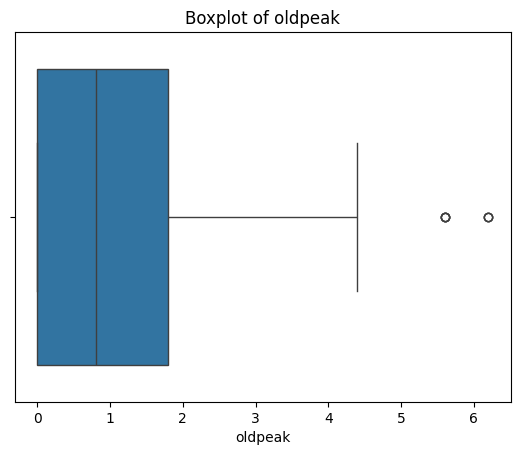

In [7]:
for col in features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.savefig(f'box_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()

Feature Importance

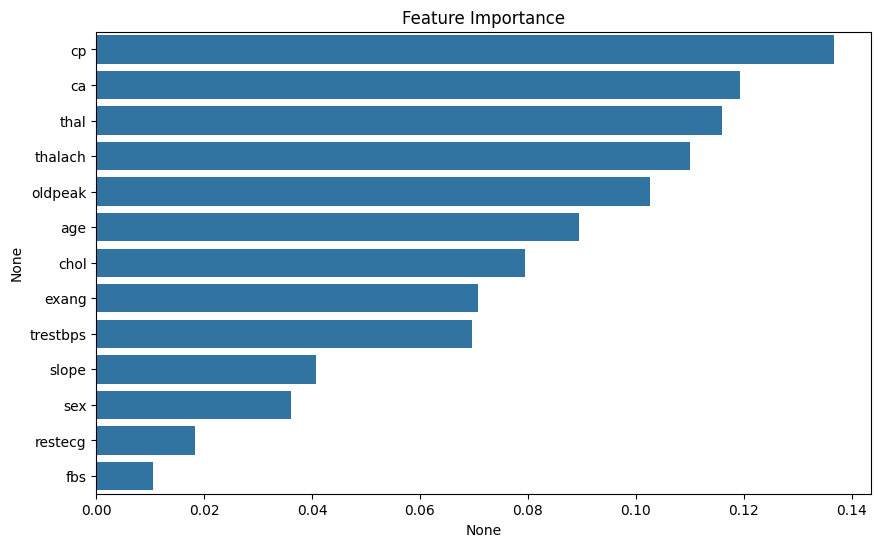

In [8]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('target', axis=1)
y = df['target']

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=importance.index)

plt.title("Feature Importance")
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Pairplot زياده

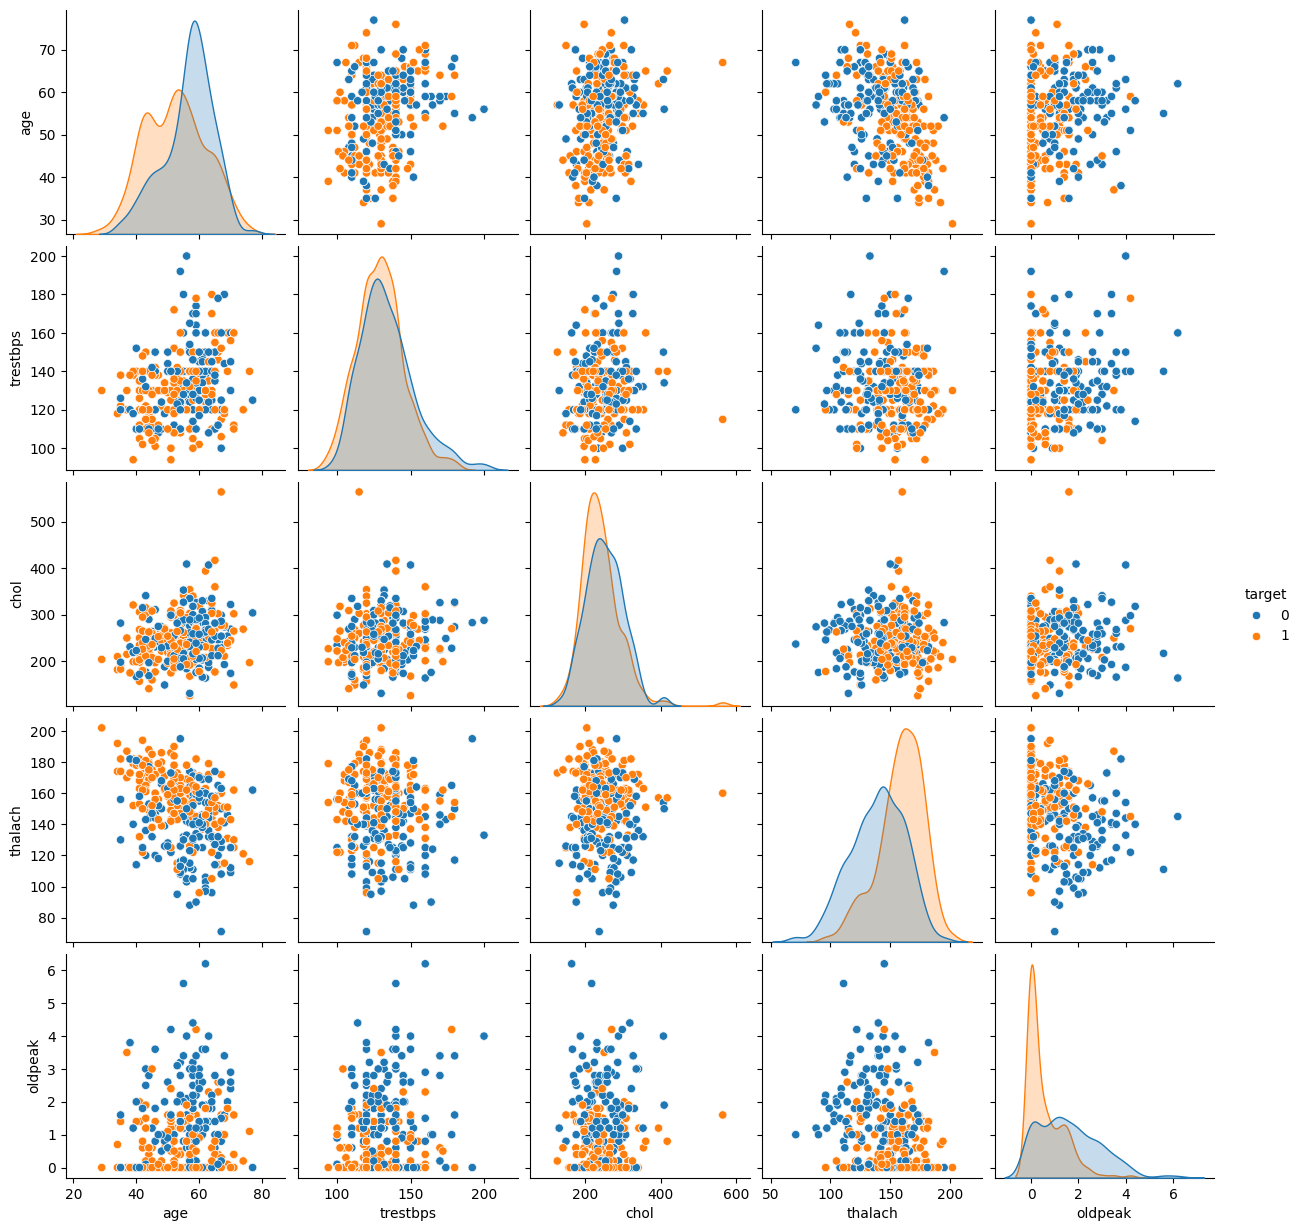

In [9]:
sns.pairplot(df[features + ['target']], hue='target')
plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

Distribution حسب Target  زياده


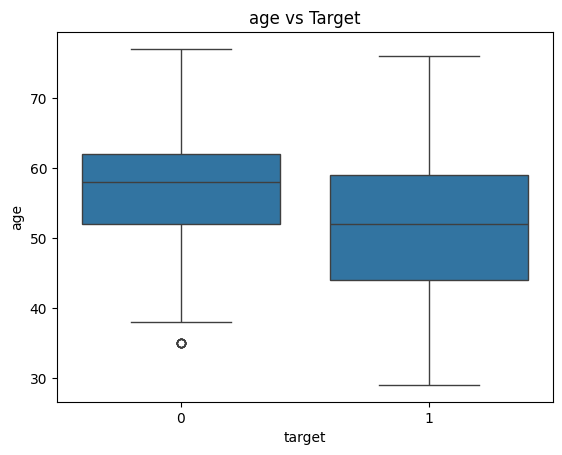

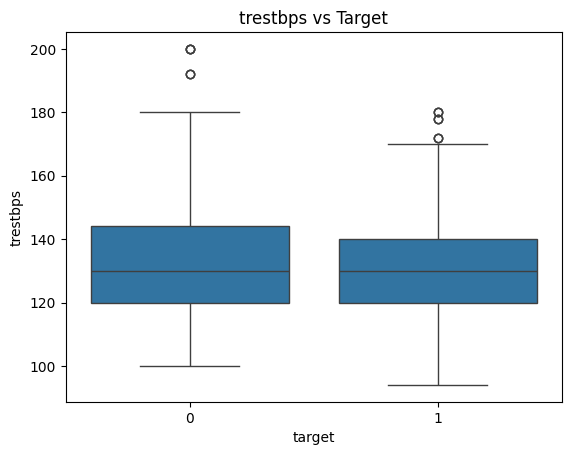

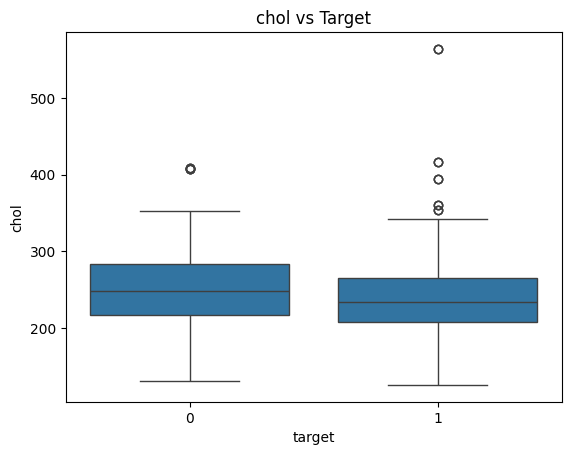

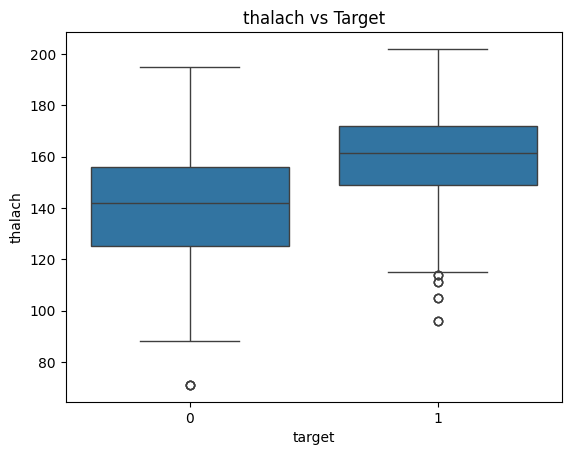

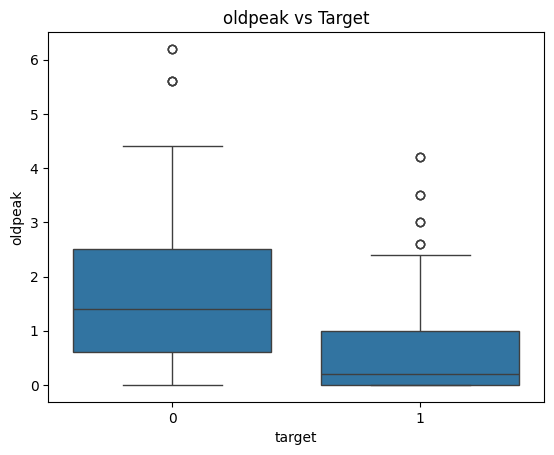

In [10]:
for col in features:
    plt.figure()
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.savefig(f'{col}_vs_target.png', dpi=300, bbox_inches='tight')
    plt.show()